# Data Scientist Professional Practical Exam Submission

**Use this template to write up your summary for submission. Code in Python or R needs to be included.**


## 📝 Task List

Your written report should include both code, output and written text summaries of the following:
- Data Validation:   
  - Describe validation and cleaning steps for every column in the data 
- Exploratory Analysis:  
  - Include two different graphics showing single variables only to demonstrate the characteristics of data  
  - Include at least one graphic showing two or more variables to represent the relationship between features
  - Describe your findings
- Model Development
  - Include your reasons for selecting the models you use as well as a statement of the problem type
  - Code to fit the baseline and comparison models
- Model Evaluation
  - Describe the performance of the two models based on an appropriate metric
- Business Metrics
  - Define a way to compare your model performance to the business
  - Describe how your models perform using this approach
- Final summary including recommendations that the business should undertake

*Start writing report here..*

## **Goal:** 
The goal of developing the machine learning model is to predict which recipes will lead to **high website traffic** when featured on the homepage, meet/beat a **≥ 0.80 recall** target for popular recipes, and translate model performance into **business metrics** (expected traffic uplift).

## **Import Libraries**

In [17]:
#Required libraries for data cleaning, validation and EDA
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Libraries for machine learning development, evaluation and performance metrics
from scipy.stats import yeojohnson
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

## **Load the dataset**

In [18]:
## **Load the dataset**
df = pd.read_csv("recipe_site_traffic_2212.csv")
print(df.head())

   recipe  calories  carbohydrate  sugar  protein   category servings  \
0       1       NaN           NaN    NaN      NaN       Pork        6   
1       2     35.48         38.56   0.66     0.92     Potato        4   
2       3    914.28         42.68   3.09     2.88  Breakfast        1   
3       4     97.03         30.56  38.63     0.02  Beverages        4   
4       5     27.05          1.85   0.80     0.53  Beverages        4   

  high_traffic  
0         High  
1         High  
2          NaN  
3         High  
4          NaN  


## **DataFrame Exploration**

In [19]:
print("---Information about the dataset ---")
print(df.info())

print("--- Statistical summary of the dataset ---")
print(df.describe())

print("-- Number of Missing Values per column --")
print(df.isna().sum())

print("-- Number of Duplicate rows --")
print(df.duplicated().sum())

print("-- Shape of the dataset --")
print(df.shape)

---Information about the dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   recipe        947 non-null    int64  
 1   calories      895 non-null    float64
 2   carbohydrate  895 non-null    float64
 3   sugar         895 non-null    float64
 4   protein       895 non-null    float64
 5   category      947 non-null    object 
 6   servings      947 non-null    object 
 7   high_traffic  574 non-null    object 
dtypes: float64(4), int64(1), object(3)
memory usage: 59.3+ KB
None
--- Statistical summary of the dataset ---
           recipe     calories  carbohydrate       sugar     protein
count  947.000000   895.000000    895.000000  895.000000  895.000000
mean   474.000000   435.939196     35.069676    9.046547   24.149296
std    273.519652   453.020997     43.949032   14.679176   36.369739
min      1.000000     0.140000      0.0300

The various columns are in the correct datatype passed. The `serving` column is not in the correct numerical datatype due to inconsistency in its values, and that is why it was passed to string and will be addressed later. No duplicate value detected; as such, no row is going to be removed. However, `calories`, `carbohydrate`, `sugar`, `protein`and `high_traffic` contains missing values.

## **Column Validation and Cleaning**

* `Serving` column: Count the different values present in the column, clean the column and convert to appropriate datatype (integer)

In [20]:
print("-- serving before cleaning --")
print(df['servings'].value_counts())

# Extract the first element and convert to integer
df['servings']= df['servings'].astype('string').str.extract(r'(\d+)').astype('int')

print("-- serving after cleaning --")
print(df['servings'].value_counts())
print(df['servings'].dtype)

-- serving before cleaning --
servings
4               389
6               197
2               183
1               175
4 as a snack      2
6 as a snack      1
Name: count, dtype: int64
-- serving after cleaning --
servings
4    391
6    198
2    183
1    175
Name: count, dtype: int64
int64


`Serving` column is in the correct format now. It is important to understand the integers are not in a numerical sense but are categorical variables. For the sake of model development, they will be left as numerical.

- `high_traffic`: The column is currently classified as a string; it's important to analyse the distribution of values in this column. As seen previously, the column has missing values which will be filled as Low and then transform the column to true (High) and false (Low). For the sake of modeling and EDA, the column is going to be converted to numerical

In [21]:
# Fill the missing values 
df['high_traffic'] = df['high_traffic'].fillna("Low")

# Covert to numbers
df['high_traffic'] = df['high_traffic'].apply(lambda x: 1 if x == 'High' else 0)
df['high_traffic'].value_counts()

high_traffic
1    574
0    373
Name: count, dtype: int64

- **category**: Check the distribution, correct the inconsistency, strip whitespace; treat as categorical and check the distibution again.

In [22]:
print("--Distribution before cleaning--")
#checking the values of category column
print(df['category'].value_counts())

# remove "Breast" from "Chicken Breast" and remove trailing spaces
df['category'] = df['category'].str.replace("Breast","").str.strip().astype('category')

print("--Distribution aftrer cleaning--")
print(df['category'].value_counts())

# Check datatype
print(df['category'].dtype)

--Distribution before cleaning--
category
Breakfast         106
Chicken Breast     98
Beverages          92
Lunch/Snacks       89
Potato             88
Pork               84
Vegetable          83
Dessert            83
Meat               79
Chicken            74
One Dish Meal      71
Name: count, dtype: int64
--Distribution aftrer cleaning--
category
Chicken          172
Breakfast        106
Beverages         92
Lunch/Snacks      89
Potato            88
Pork              84
Vegetable         83
Dessert           83
Meat              79
One Dish Meal     71
Name: count, dtype: int64
category


In [23]:
cols_with_missing_value = ['calories', 'carbohydrate', 'sugar', 'protein', 'servings']
# Fill the missing values in the cols_with_missing_value columns with the mean of their respective category and servings groups
for col in cols_with_missing_value: 
    df[col] = df[col].fillna(df.groupby(["category", "servings"])[col].transform('mean'))

C:\Users\PC\AppData\Local\Temp\ipykernel_9240\2393503281.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[col] = df[col].fillna(df.groupby(["category", "servings"])[col].transform('mean'))


Check validation

In [24]:
print("--Dataset information--")
print(df.info())

print("--Number of missing values per column--")
print(df.isna().sum())

--Dataset information--
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   recipe        947 non-null    int64   
 1   calories      947 non-null    float64 
 2   carbohydrate  947 non-null    float64 
 3   sugar         947 non-null    float64 
 4   protein       947 non-null    float64 
 5   category      947 non-null    category
 6   servings      947 non-null    int64   
 7   high_traffic  947 non-null    int64   
dtypes: category(1), float64(4), int64(3)
memory usage: 53.2 KB
None
--Number of missing values per column--
recipe          0
calories        0
carbohydrate    0
sugar           0
protein         0
category        0
servings        0
high_traffic    0
dtype: int64


The data is completely cleaned and validated with the correct datatype devoid of any missing values.

Save the cleaned data to csv

In [25]:
df.to_csv("cleaned_recipe_site_traffic_2212.csv", index=False)

## **Exploratory Analysis**

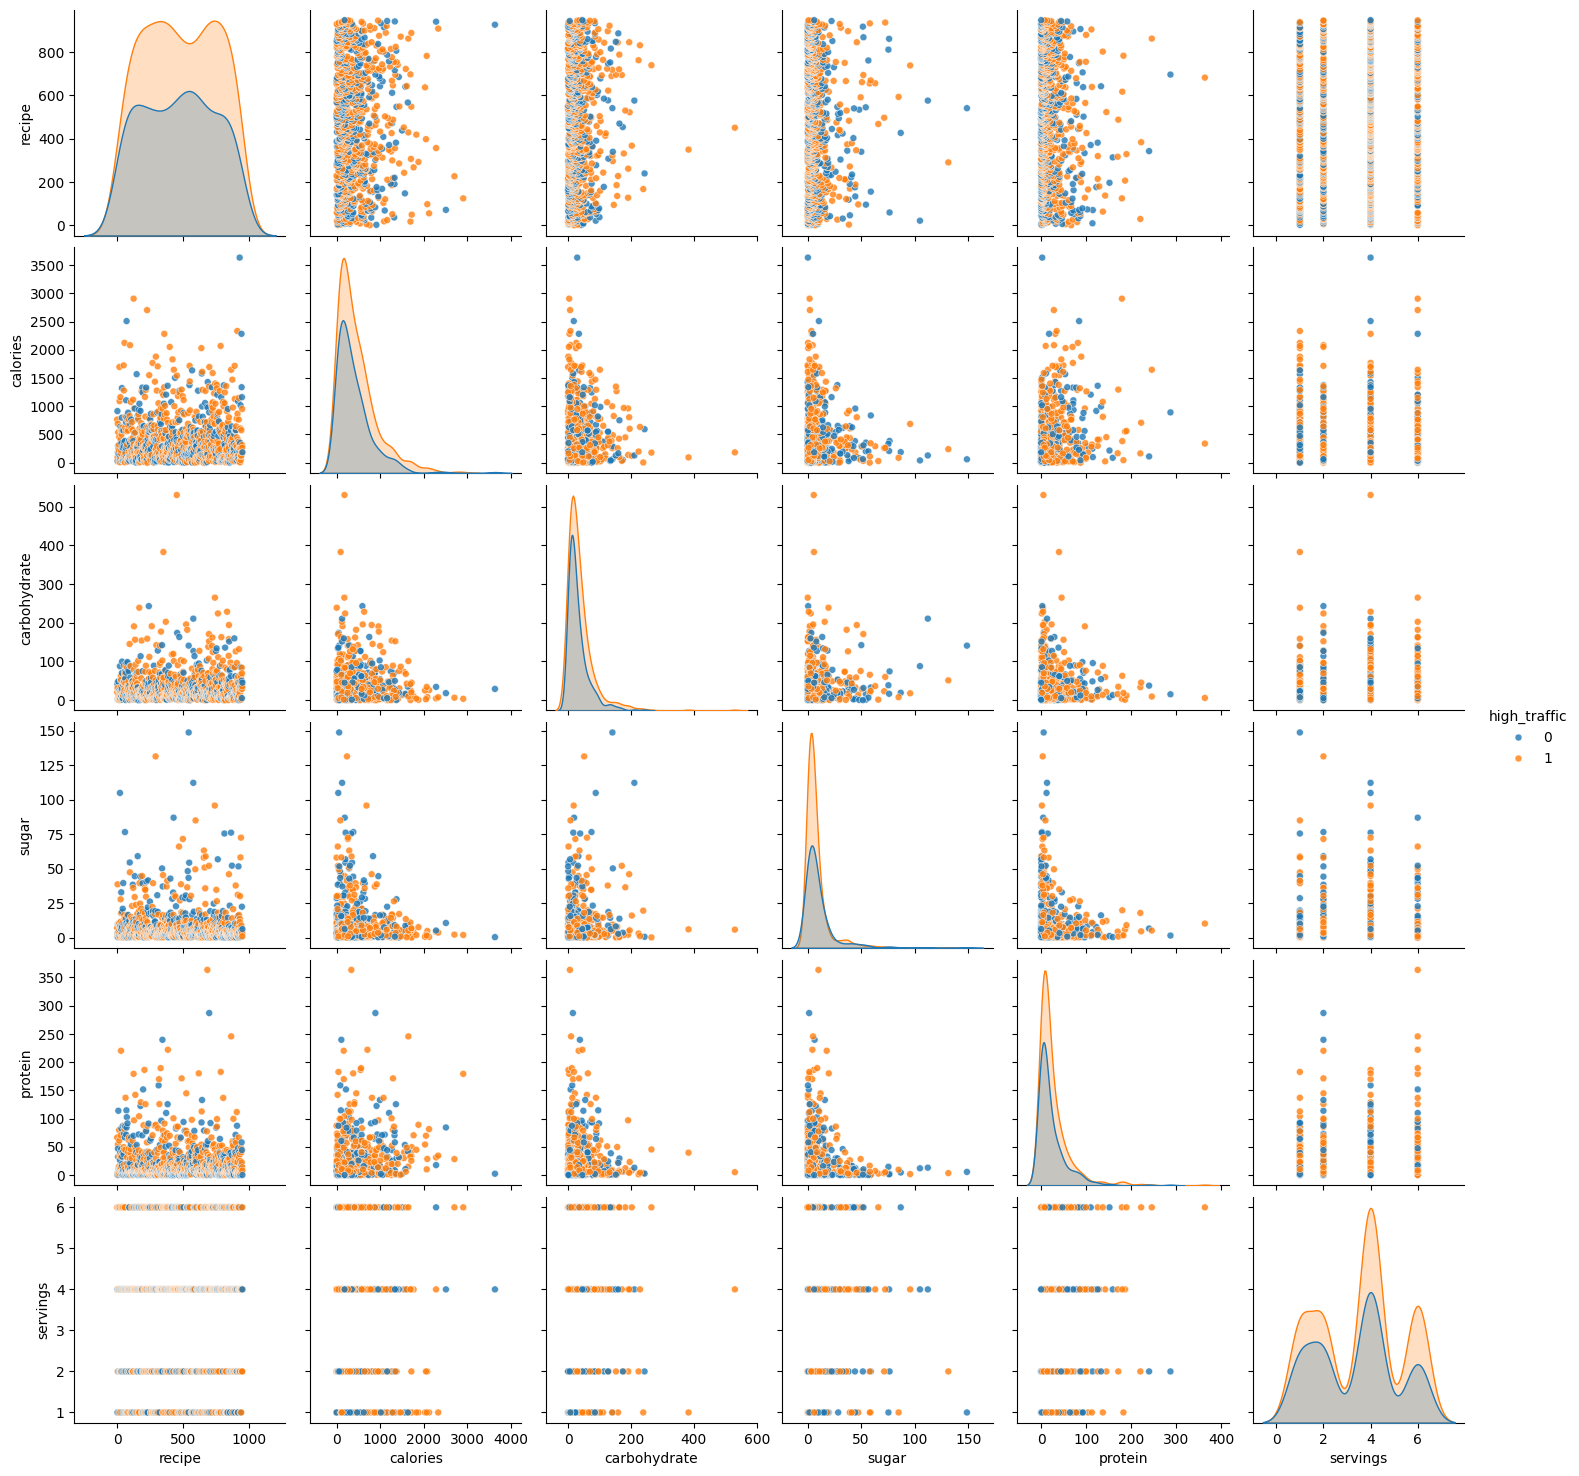

In [26]:
sns.pairplot(df, hue='high_traffic', diag_kind='kde', plot_kws={'alpha':0.8,'s':25})
plt.show()

The correlation between the various columns seems to be very weak (insignificant).

**Numeric Variables**

From the heatmap below, we can conclude that there is a moderate linear negative relationship in 5 variables - calories, carbohydrate, sugar, protein, servings. All values are close to 0, so they are weakly connected. 

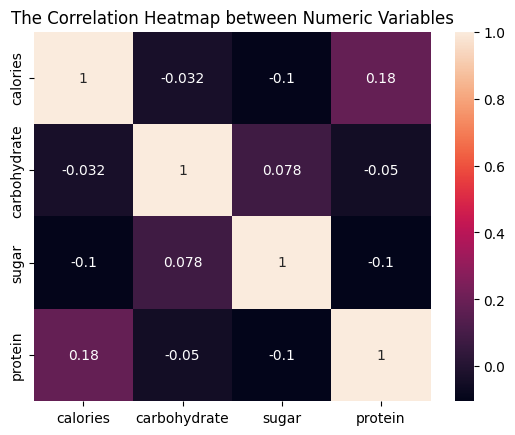

In [27]:
numerical_cols = ['calories','carbohydrate','sugar','protein']
sns.heatmap(df[numerical_cols].corr(), annot=True).set(title='The Correlation Heatmap between Numeric Variables');

The heatmap displayed a moderate linear negative relationship in 5 variables - calories, carbohydrate, sugar, protein and servings. All values are close to 0, so they are weakly connected. 

**Distributions**  
Examine the univariate distributions for the four nutritional features to understand skew and spot extreme values (often legitimate for desserts/meats).

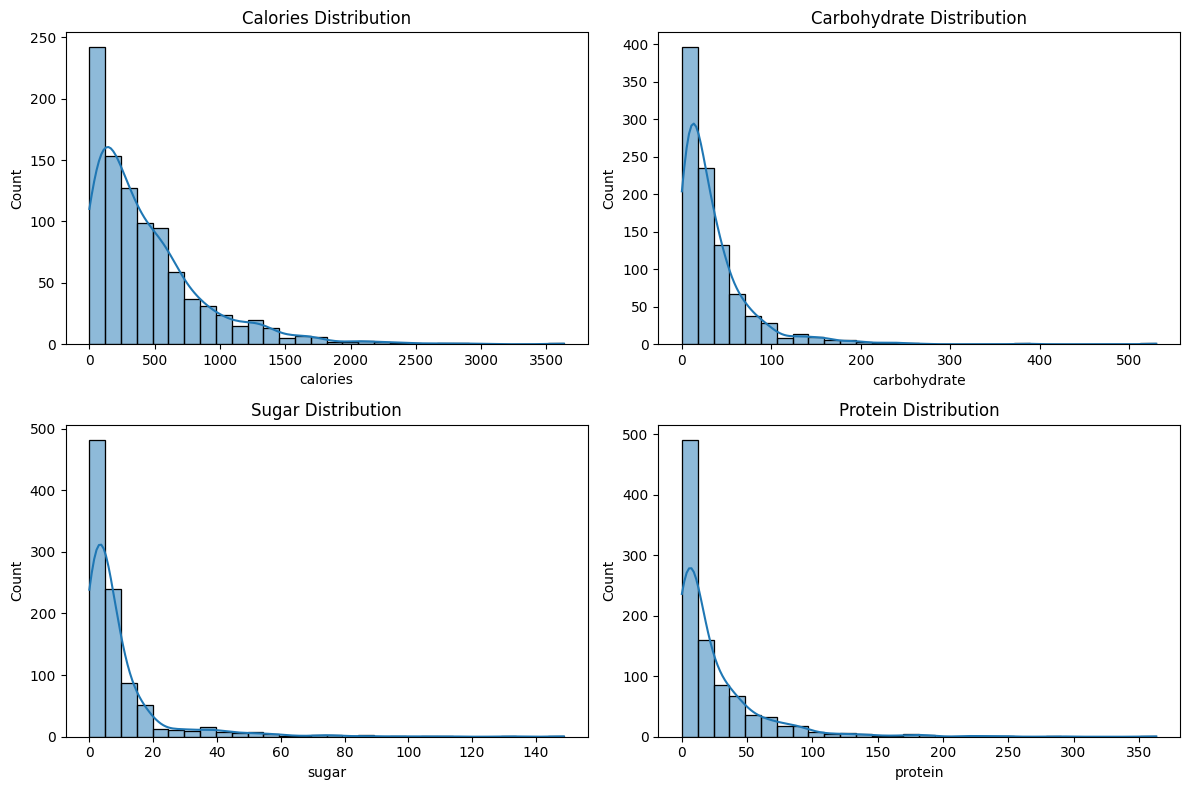

In [28]:
fig, axes = plt.subplots(2,2, figsize=(12,8))
for ax, col in zip(axes.ravel(), ['calories','carbohydrate','sugar','protein']):
    sns.histplot(df[col], bins=30, kde=True, ax=ax)
    ax.set_title(f'{col.title()} Distribution')
plt.tight_layout(); 
plt.show()

Kernel Density Estimation (KDE) was included to help us understand the distribution. Observations shows that the dataset primarily contains lower values for the calorie and nutritional components of foods or beverages. The dataset is a right-skewed distribution.

**Category Mix & High‑Traffic Rate by Category**  
This shows how many recipes belong to each category and the observed share labeled as "High". This helps spot categories that tend to perform better.


C:\Users\PC\AppData\Local\Temp\ipykernel_9240\132268172.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rate = df.groupby('category')['high_traffic'].mean()


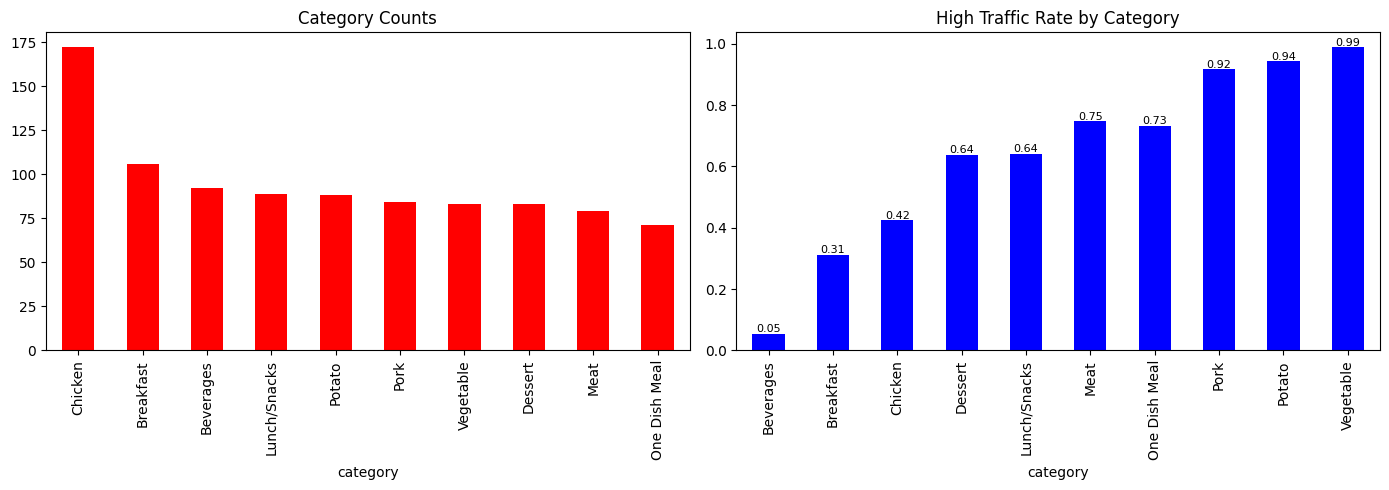

In [29]:
# Setup the figure
fig, ax = plt.subplots(1,2, figsize=(14,5))

# Letf plot: Category count
df['category'].value_counts().plot(kind='bar', ax=ax[0], color='r', title='Category Counts')

# Right plot: High traffic
# Determine the mean
rate = df.groupby('category')['high_traffic'].mean()
rate.plot(kind='bar', ax=ax[1], color='b', title='High Traffic Rate by Category')

for i,v in enumerate(rate):
    ax[1].text(i, v+0.005, f"{v:.2f}", ha='center', fontsize=8)
plt.tight_layout(); 
plt.show()


**Bivariate Relationship (Calories vs Protein)**  
Higher‑calorie meals often contain higher protein; the scatter can hint at non‑linear interactions, making tree‑based models a good comparison to a linear baseline.

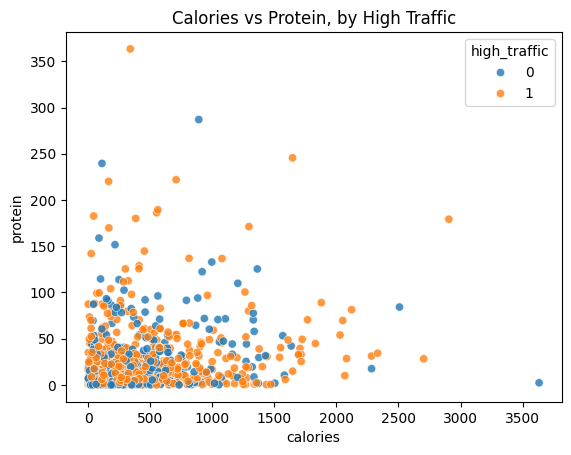

In [30]:
sns.scatterplot(x='calories', y='protein', hue='high_traffic', 
                data=df, alpha=0.8)
plt.title('Calories vs Protein, by High Traffic')
plt.show()

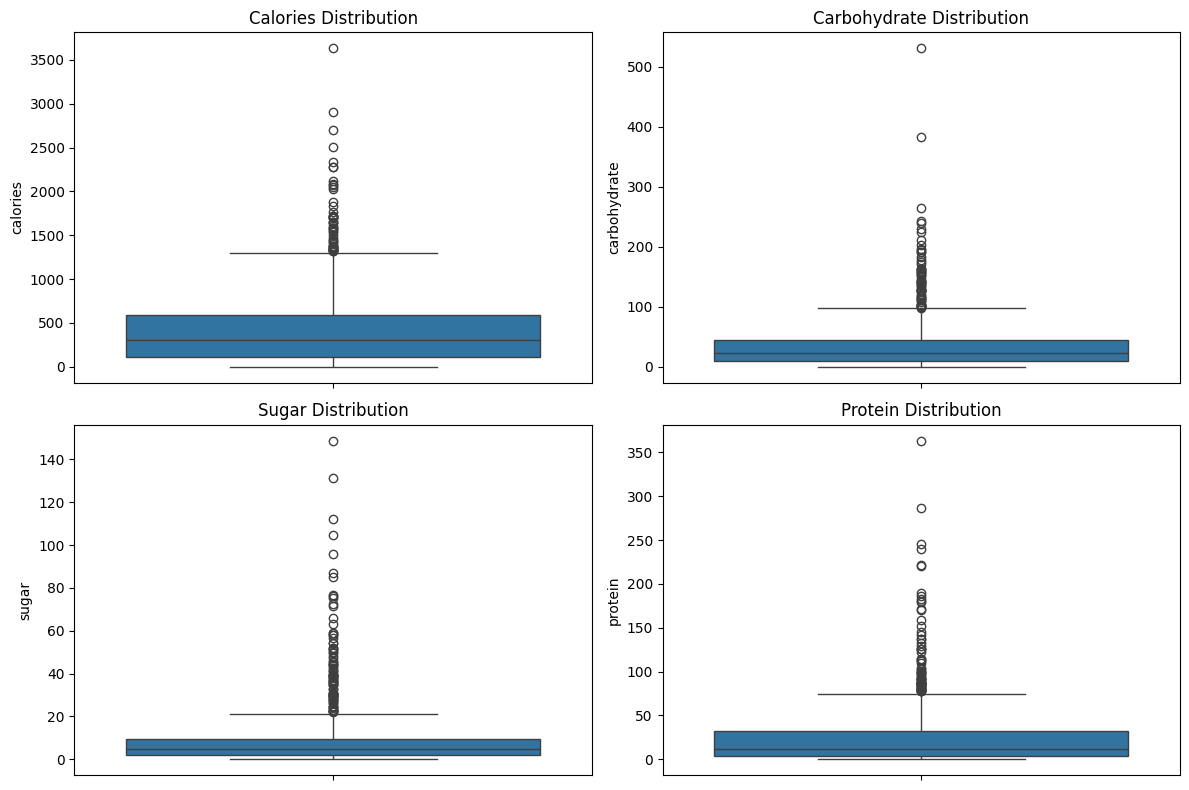

In [31]:
#creating subplots with the desired number of rows and columns
fig, axes = plt.subplots(2,2, figsize=(12,8))
for ax, col in zip(axes.ravel(), ['calories','carbohydrate','sugar','protein']):
    sns.boxplot(df[col], ax=ax)
    ax.set_title(f'{col.title()} Distribution')
plt.tight_layout(); 
plt.show()

The plots clearly confirm the presence of outliers, demonstrate the right-skewed distribution of these columns, and underline the relevance of using the median for analysis.

Additionally, we can further investigate the median values of calories and nutritional components by category. This can be done by grouping the data by category and then computing the median for each group.

In [32]:
# Let group by category column and find total number of servings
category_medians = df.groupby("category")['calories','carbohydrate','sugar','protein'].median().reset_index()

print("--Median of each category--")
print(category_medians)

C:\Users\PC\AppData\Local\Temp\ipykernel_9240\462246462.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_medians = df.groupby("category")['calories','carbohydrate','sugar','protein'].median().reset_index()


ValueError: Cannot subset columns with a tuple with more than one element. Use a list instead.

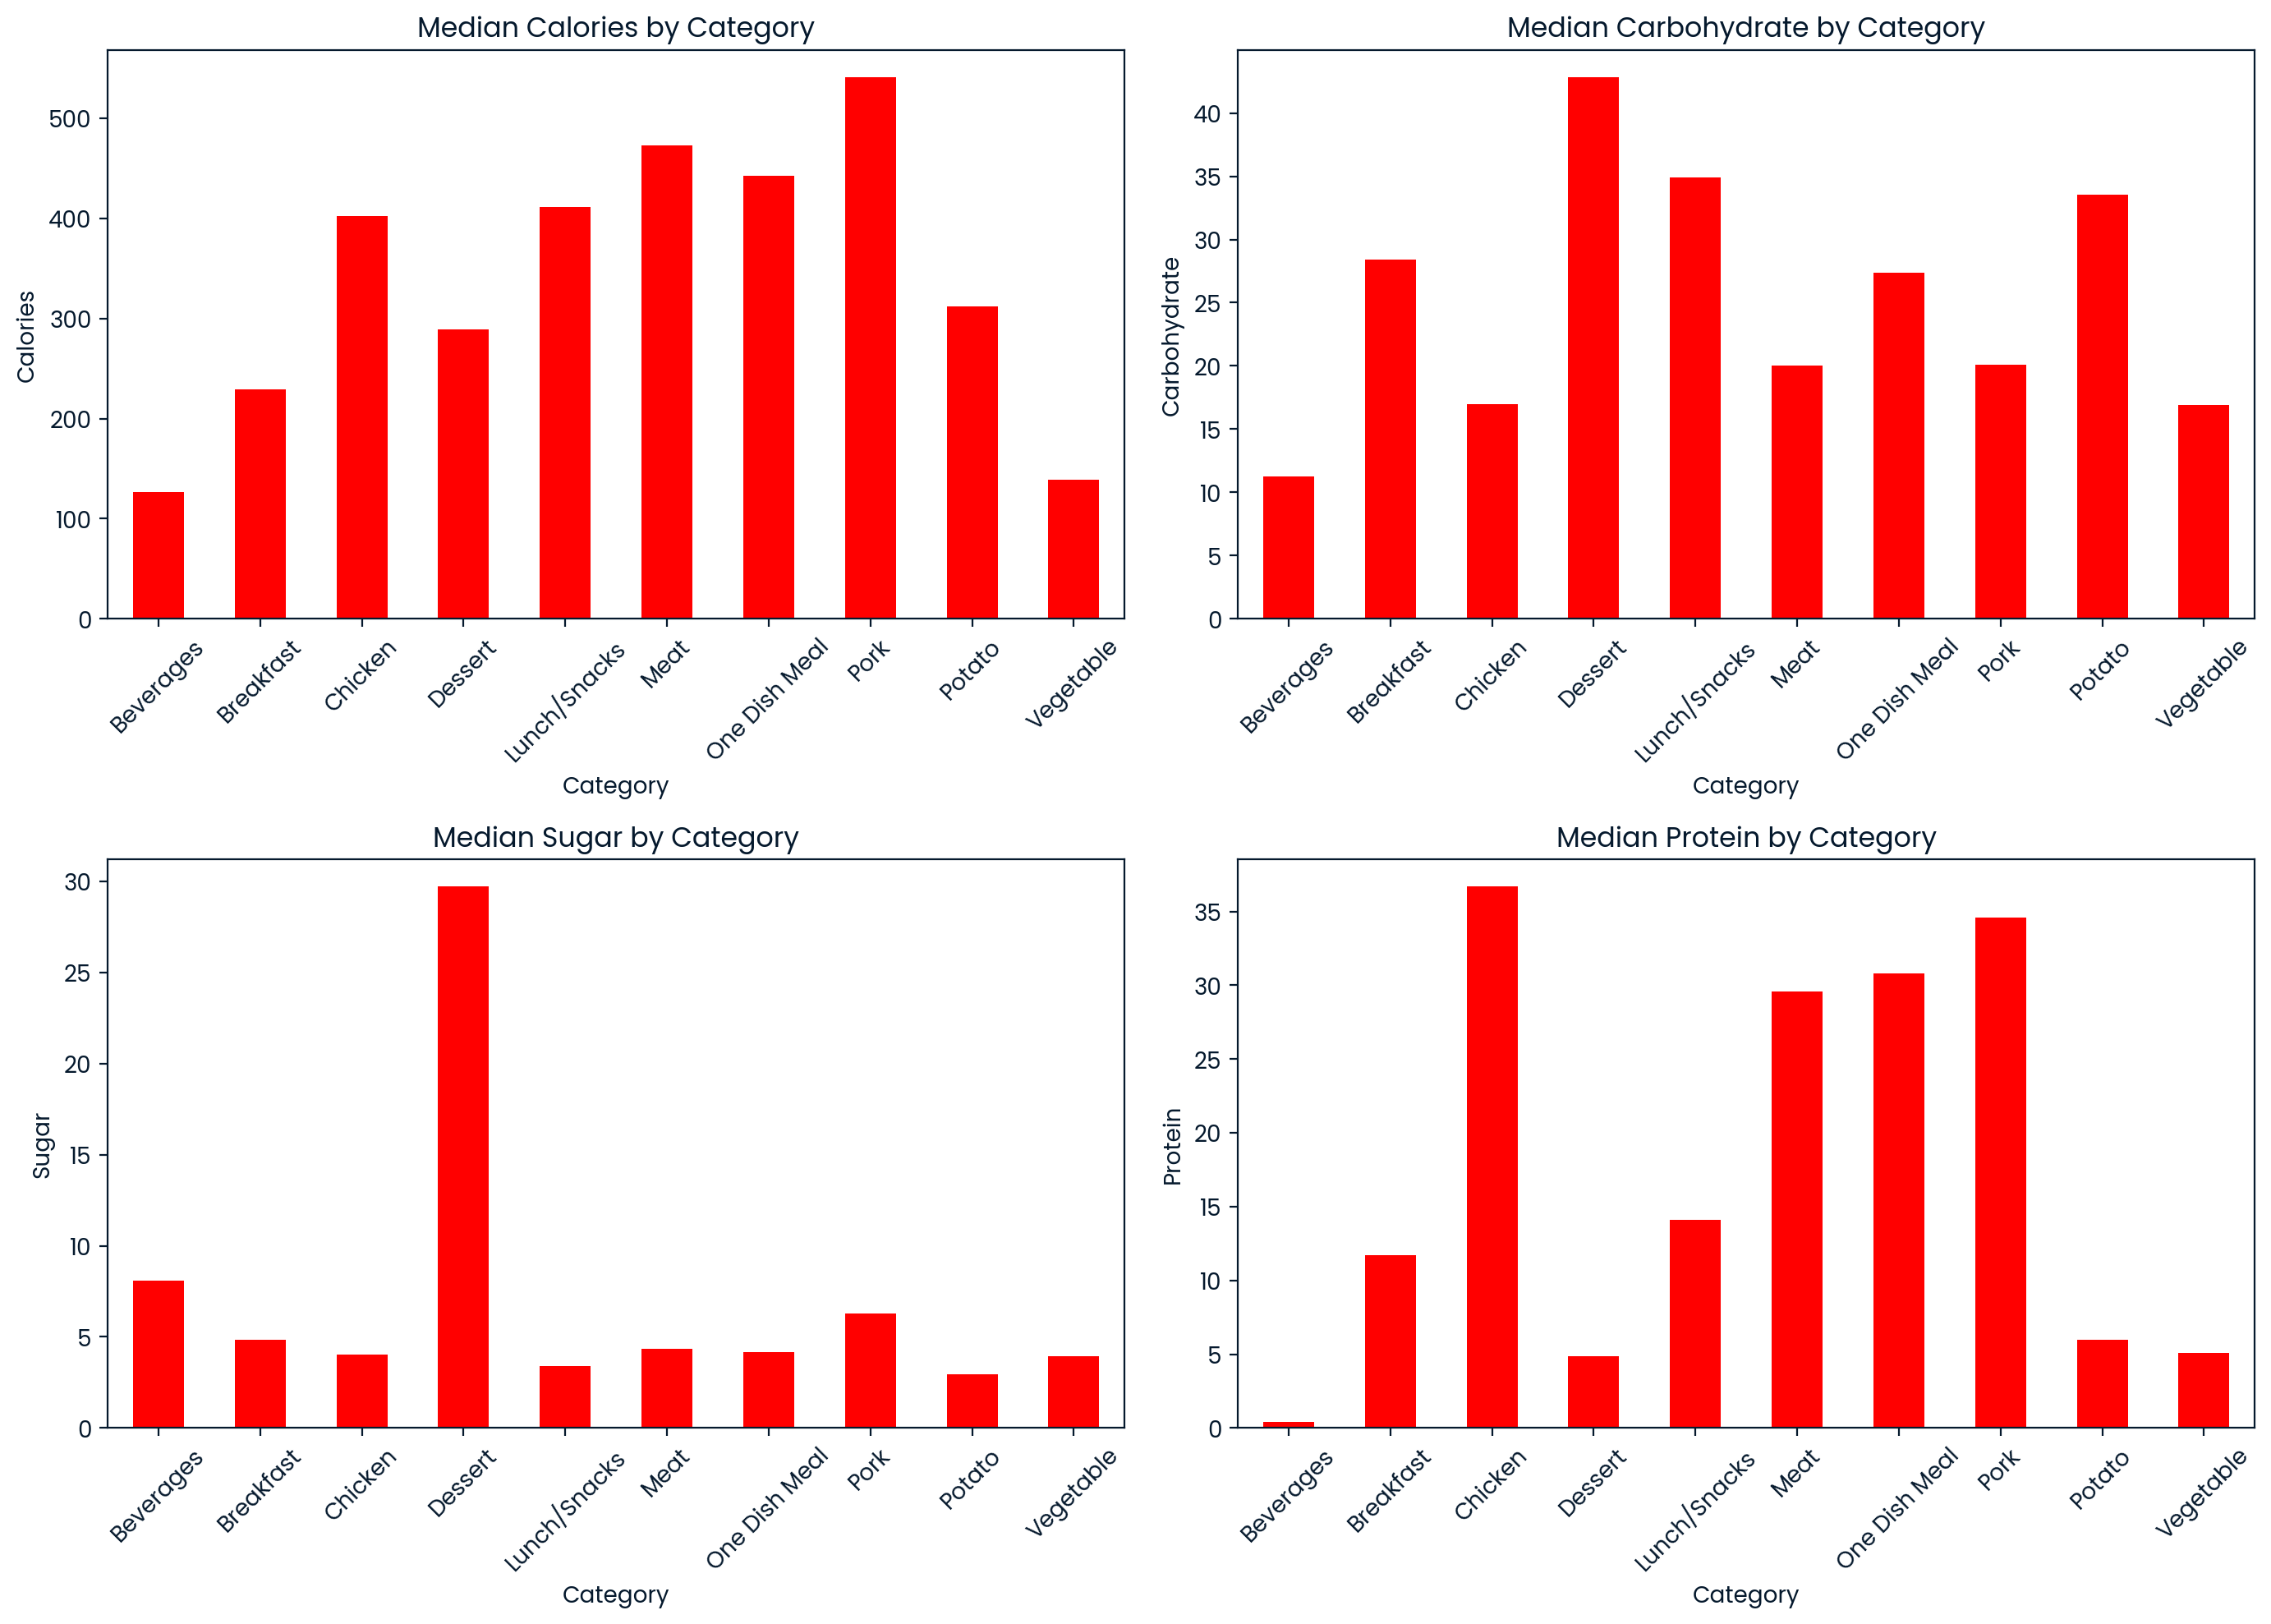

In [ ]:
# setting up the figure and axes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))  
axes = axes.flatten() 

# loop over the columns and create a bar plot in each subplot
for i, column in enumerate(['calories','carbohydrate','sugar','protein']):
    category_medians.plot(x="category", y=column, kind="bar", ax=axes[i], legend=False, color='r')
    axes[i].set_title(f"Median {column.capitalize()} by Category")
    axes[i].set_xlabel("Category")
    axes[i].set_ylabel(column.capitalize())
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)

# adjust layout to prevent overlap
plt.tight_layout()

# display the plot
plt.show()


The medians for calories and nutritional components are not as symmetrical as expected and differ based on the type of food and beverages.

Next, we will explore the relationship between servings and high traffic status.

- Servings vs. High Traffic

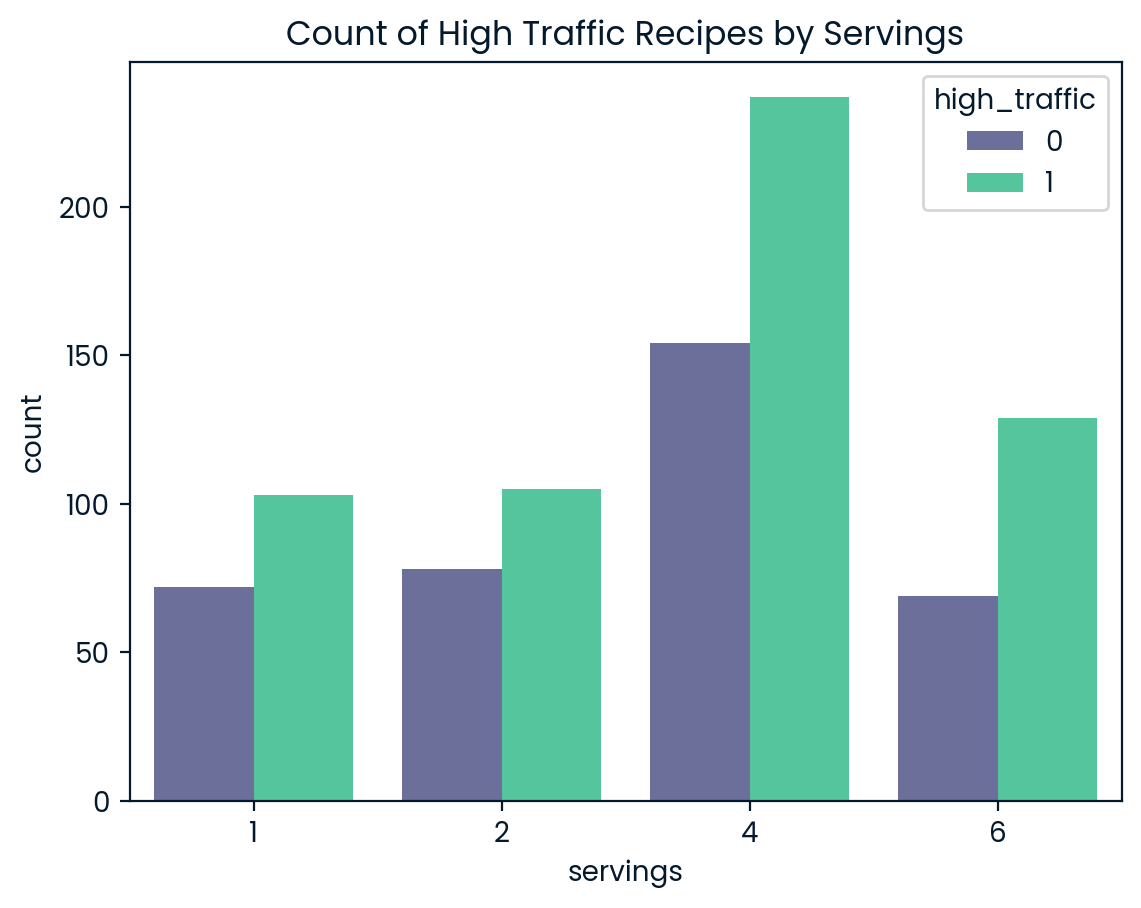

In [ ]:
sns.countplot(df, x="servings", hue="high_traffic")
plt.title("Count of High Traffic Recipes by Servings")
plt.show()

The plot and the normalized data clearly show that recipes serving six people tend to have higher traffic rates.

- Category vs. High Traffic: Let's see how high traffic varies across various categories.


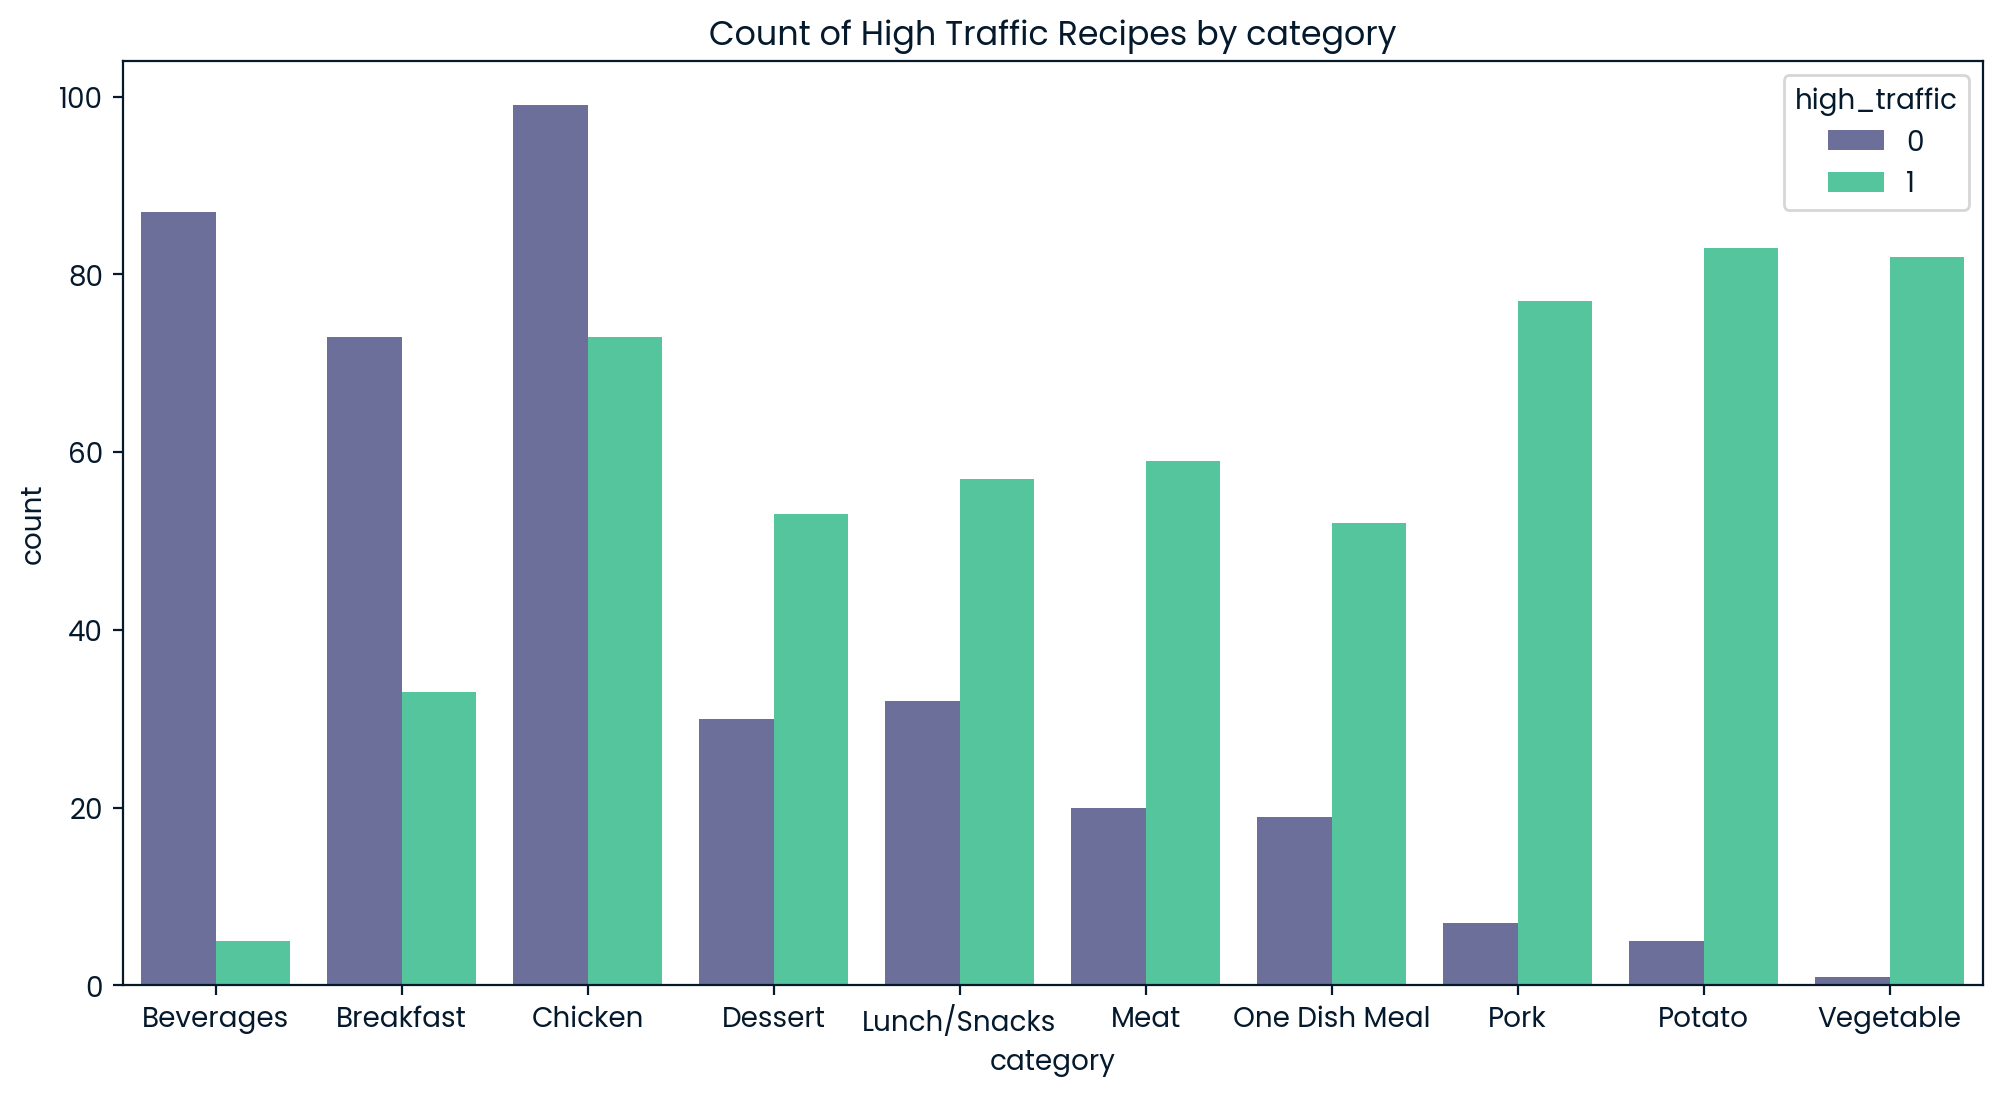

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(df, x="category", hue="high_traffic")
plt.title("Count of High Traffic Recipes by category")
plt.show()

The categories "Vegetable", "Potato" and "Pork" have the most traffic, while the "Beverages" category seems to have the least impact on traffic.

## **Model Development**

From the EDA above, it's evidently clear that we are dealing with a binary classification problem. Hence, we are going to deploy machine learning models to predict if a recipe will generate high traffic or low traffic.

To do this, there is a need to address the outliers presence in our dataset. This can be achieve by determining the interquartile range (IQR) and drop any value above or below the lower and upper boundary of the IQR

In [ ]:
#function to calculate upper and lower boundaries of columns
def calculate_outlier_limits(data, factor=1.5):
    # Find 25% and 75% percentiles
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    
    #calculate IQR
    iqr = q3 - q1
    
    #calculate lower and upper boundaries
    lower_limit = q1 - (factor * iqr)
    upper_limit = q3 + (factor * iqr)
    return lower_limit, upper_limit

In [ ]:
#select numerical columns
numerical_columns = ['calories', 'carbohydrate', 'sugar', 'protein']

#calculate outlier limits for each numerical column
outlier_limits = {}
for column in numerical_columns:
    lower_limit, upper_limit = calculate_outlier_limits(df[column])
    outlier_limits[column] = (lower_limit, upper_limit)

#check the calculated outlier limits for each column
for column, limits in outlier_limits.items():
    print(f"Column: {column}")
    print(f"Lower Limit: {limits[0]}")
    print(f"Upper Limit: {limits[1]}")
    print("--------------------------------")

Column: calories
Lower Limit: -605.6874999999999
Upper Limit: 1314.5724999999998
--------------------------------
Column: carbohydrate
Lower Limit: -44.2725
Upper Limit: 98.1475
--------------------------------
Column: sugar
Lower Limit: -9.860000000000001
Upper Limit: 21.220000000000002
--------------------------------
Column: protein
Lower Limit: -39.8775
Upper Limit: 75.7025
--------------------------------


The lower boundary poses no threat to the dataset, while the upper boundary does. To avoid bias, the **Yeo-Johnson Transformation** will be used to transform the dataset. The `recipe` column has no impact on our model and will be drop (i.e just an id column)

In [ ]:
#drop receipe, 
df = df.drop('recipe', axis=1)

In [ ]:
#specifying the numerical columns to plot
numerical_columns =  df.select_dtypes(include='float').columns

#filter the dataset based on the outlier limits
transformed_data = df.copy()
for column, limits in outlier_limits.items():
    lower_limit, upper_limit = limits
    # Yeo-Johnson Transformation
    transformed_data[column] = yeojohnson(transformed_data[column])[0]                      

# Check the filtered dataset
print(transformed_data.head())

    calories  carbohydrate     sugar  ...   category servings  high_traffic
0  18.063799      3.645622  1.716826  ...       Pork        6             1
1   5.999621      4.570564  0.483029  ...     Potato        4             1
2  19.117629      4.722198  1.234766  ...  Breakfast        1             0
3   8.916501      4.231122  2.641840  ...  Beverages        4             1
4   5.343929      1.112516  0.555951  ...  Beverages        4             0

[5 rows x 7 columns]


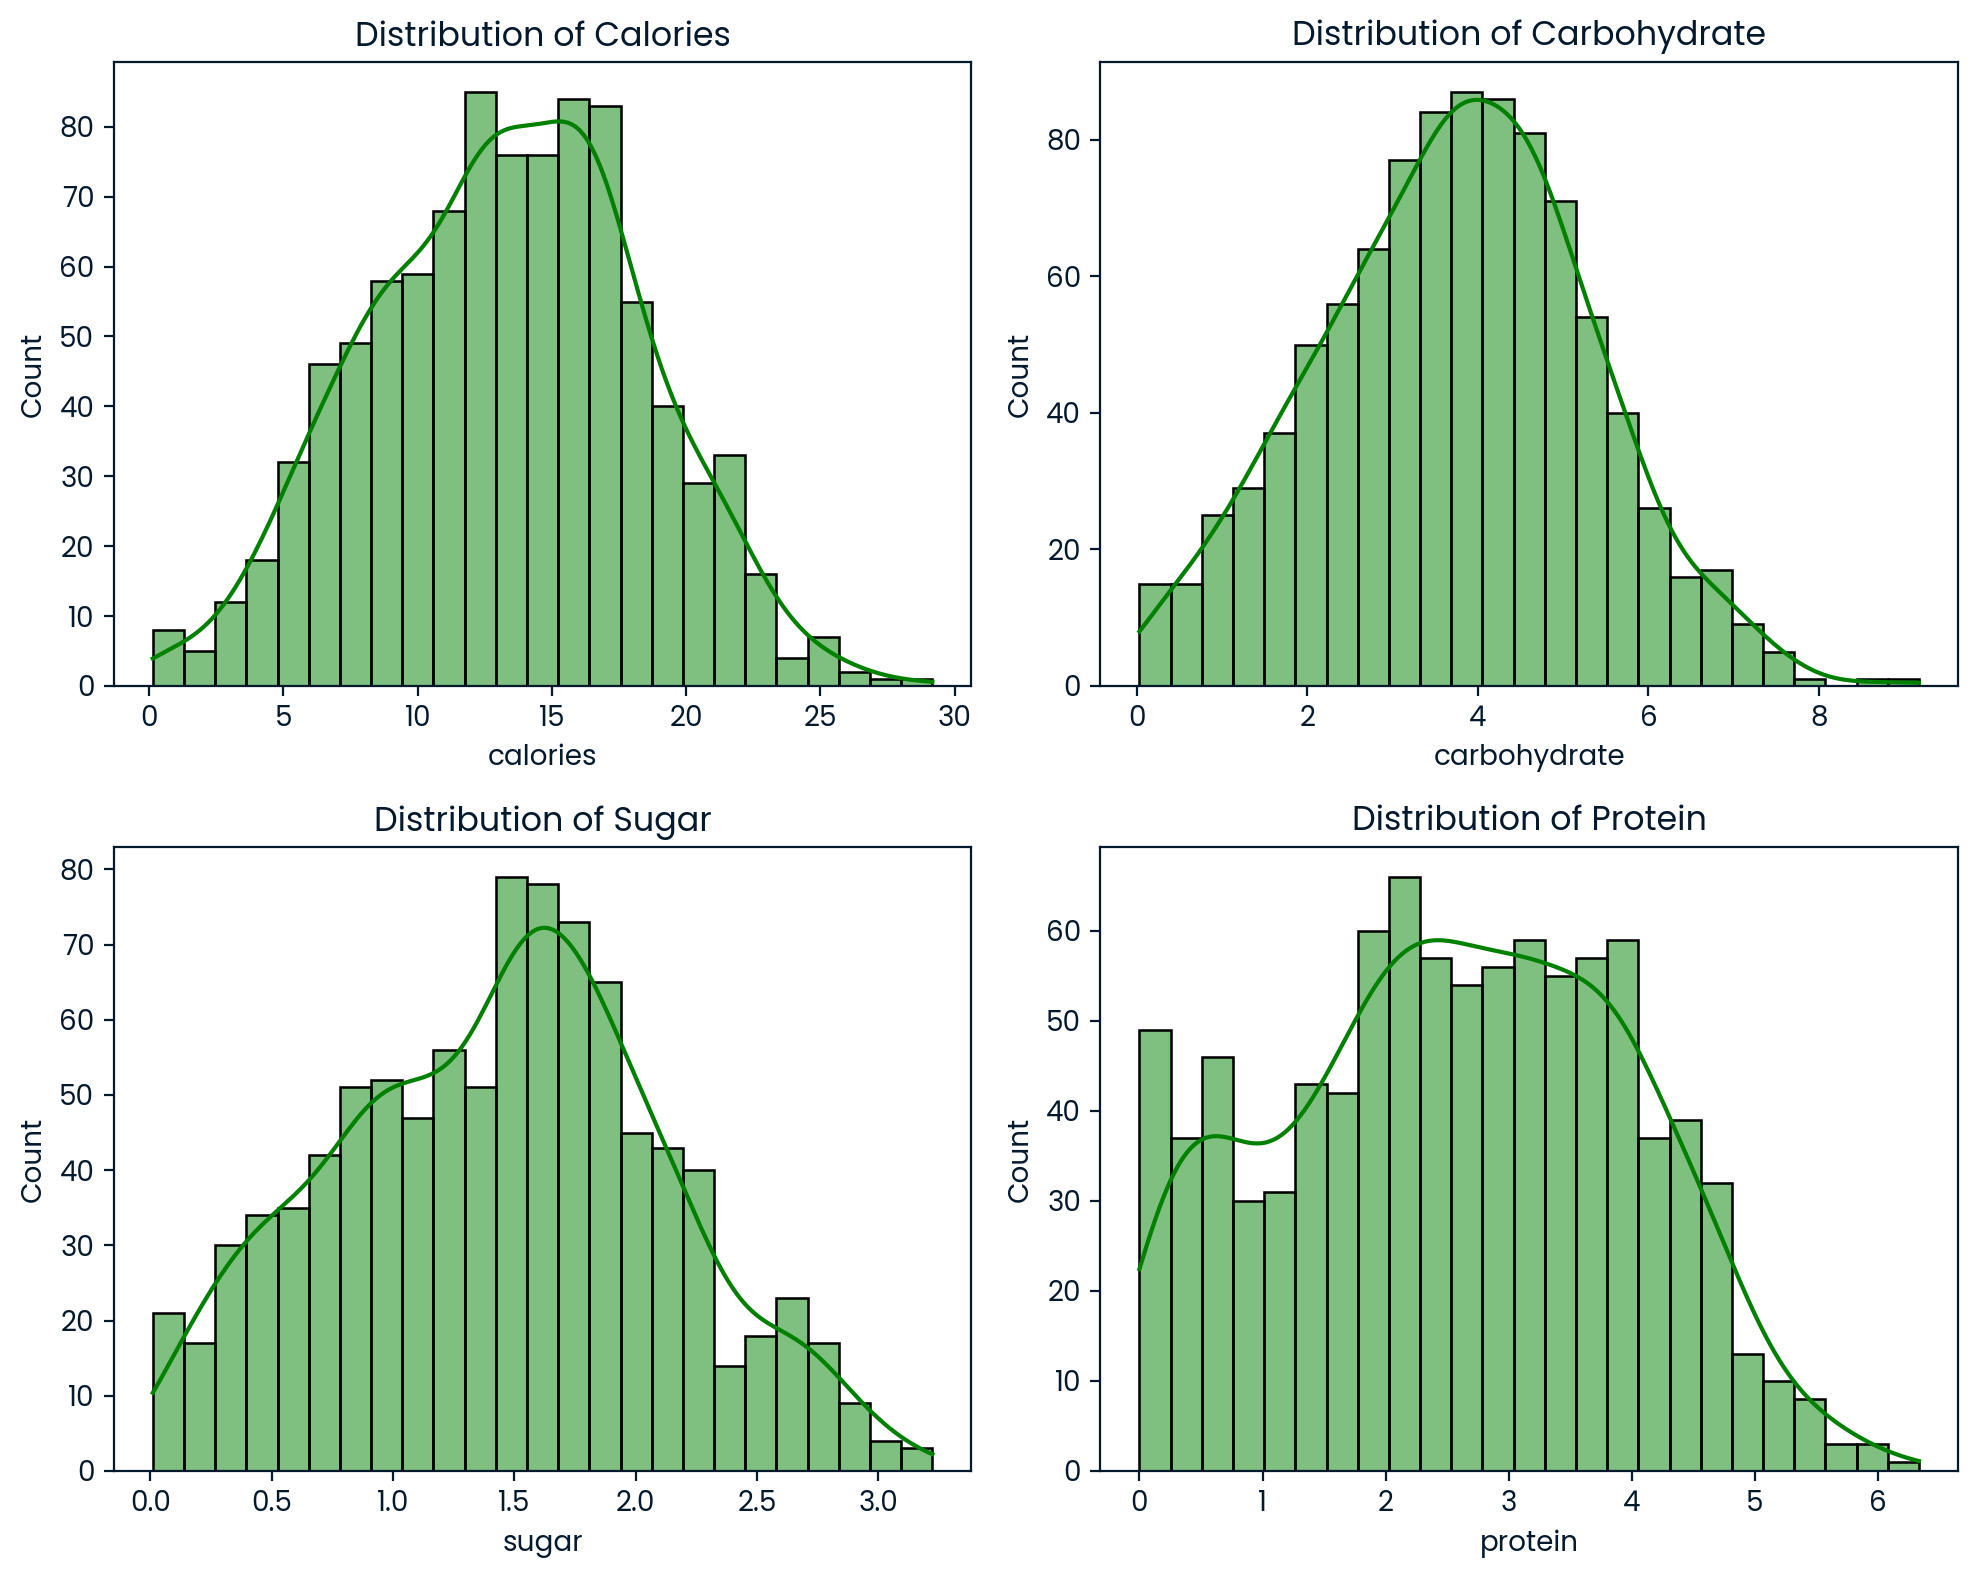

In [ ]:
# Visualise the distribution
plt.figure(figsize=(10, 8))
#iterating over each column and create a bar plot
for i, column in enumerate(numerical_columns):
    plt.subplot(2,2, i+1)
    sns.histplot(data=transformed_data, x=column, kde=True, bins=25, color='g')
    plt.title(f"Distribution of {column.capitalize()}")

#adjust the spacing between subplots if needed
plt.tight_layout()
plt.show()

`calorie`, `sugar`, `carbohydrate` and `protein` behave in normal distribution manner, showing how normally the dataset is distributed after transformation.

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, PowerTransformer, MinMaxScaler


Let's convert the `category` column to numerical using oneHotEncoder

In [ ]:
# Convert the categorical variables into numeric features
labelencoder = LabelEncoder()
encoded_data = labelencoder.fit_transform(df['category'])

# Wrap the numpy array in a series 
encoded_series = pd.Series(encoded_data, index=df.index, name='category_encoded')

# Concat with original data and drop the old column
encoded_df = pd.concat([df.drop('category', axis=1), encoded_series], axis =1)

#encoded_df.head()
encoded_df.head()

,calories,carbohydrate,sugar,protein,servings,high_traffic,category_encoded
0,764.641333,20.072,7.013333,66.528,6,1,7
1,35.480000,38.560,0.660000,0.920,4,1,8
2,914.280000,42.680,3.090000,2.880,1,0,1
3,97.030000,30.560,38.630000,0.020,4,1,0
4,27.050000,1.850,0.800000,0.530,4,0,0


## **Model Setup**

* Data will be split into feature and target variable, since traffic need to be predicted, `high_traffic` will be the target variable
* The dataset is going to be split into train and test data
* A model will be developed and its performance will be compared with other models
* The models will be fit, train and make predictions

In [ ]:
# Split into feature (x) and target(y)
X = encoded_df.drop("high_traffic", axis=1)
y = encoded_df["high_traffic"]

print("--Feature Variable--")
print(X.head())

print("--Target Variable--")
print(y.head())

--Feature Variable--
     calories  carbohydrate      sugar  protein  servings  category_encoded
0  764.641333        20.072   7.013333   66.528         6                 7
1   35.480000        38.560   0.660000    0.920         4                 8
2  914.280000        42.680   3.090000    2.880         1                 1
3   97.030000        30.560  38.630000    0.020         4                 0
4   27.050000         1.850   0.800000    0.530         4                 0
--Target Variable--
0    1
1    1
2    0
3    1
4    0
Name: high_traffic, dtype: int64


In [ ]:
#split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [ ]:
#create function to fit and train the model, make prediction, and return evaluation metrics
def develop_model(model, X_train, y_train, X_test, y_test):
    evaulation_metrics = {}

    #fit the model
    model.fit(X_train, y_train)

    #predict for train and test data
    model_pred_train = model.predict(X_train)
    model_pred_test = model.predict(X_test)

    #find evaluation parameters for train data
    model_accuracy_train = accuracy_score(y_train, model_pred_train)
    model_precision_train = precision_score(y_train, model_pred_train)
    model_recall_train = recall_score(y_train, model_pred_train)
    model_f1_train = f1_score(y_train, model_pred_train)
    model_cm_train = confusion_matrix(y_train, model_pred_train)
    
    evaulation_metrics['train'] = [model_accuracy_train, model_precision_train, model_recall_train, model_f1_train, model_cm_train]

    #find evaluation parameters for test data
    model_accuracy_test = accuracy_score(y_test, model_pred_test)
    model_precision_test = precision_score(y_test, model_pred_test)
    model_recall_test = recall_score(y_test, model_pred_test)
    model_f1_test = f1_score(y_test, model_pred_test)
    model_cm_test = confusion_matrix(y_test, model_pred_test)
    
    evaulation_metrics['test'] = [model_accuracy_test, model_precision_test, model_recall_test, model_f1_test, model_cm_test]

    return evaulation_metrics

### **Logistic Regression**

In [ ]:
# base mode: logistic regression
logreg = LogisticRegression()
logreg_evaluation_metrics = develop_model(logreg, X_train, y_train, X_test, y_test)

In [ ]:
#Comparison Models
# 1. decision tree
dec_tree = DecisionTreeClassifier()
dec_tree_evaluation_metrics = develop_model(dec_tree, X_train, y_train, X_test, y_test)

# 2. random forest
rand_for = RandomForestClassifier()
rand_for_evaluation_metrics = develop_model(rand_for, X_train, y_train, X_test, y_test)

# 3. support vector machines
svm = SVC()
svm_evaluation_metrics = develop_model(svm, X_train, y_train, X_test, y_test)

### **Performance metric**

In [ ]:
def display_metrics(evaluation_metrics):
    print("  Accuracy:", evaluation_metrics[0])
    print("  Precision:", evaluation_metrics[1])
    print("  Recall:", evaluation_metrics[2])
    print("  F1-Score:", evaluation_metrics[3])
    print("  Confusion Matrix:")
    print(evaluation_metrics[4])

## **ModeL Evaluation**

### **Comparison Models**

1. Logistic regression evaluation

In [ ]:
#print the evaluation metrics and confusion matrices for Logistic Regression
print("Logistic Regression Train:")
display_metrics(logreg_evaluation_metrics['train'])

print("Logistic Regression Test:")
display_metrics(logreg_evaluation_metrics['test'])

Logistic Regression Train:
  Accuracy: 0.760898282694848
  Precision: 0.8083700440528634
  Recall: 0.7960954446854663
  F1-Score: 0.8021857923497268
  Confusion Matrix:
[[209  87]
 [ 94 367]]
Logistic Regression Test:
  Accuracy: 0.7631578947368421
  Precision: 0.8035714285714286
  Recall: 0.7964601769911505
  F1-Score: 0.7999999999999999
  Confusion Matrix:
[[55 22]
 [23 90]]


There is a small difference between the _test_ results and the _train_ results, although it cannot amount to overfitting but shows limited data were used for the training.

The train precision metrics is currently 80.83%, thankfully, it satisfy our target requirement 

2. Decision tree evaluation

In [ ]:
#print the evaluation metrics and confusion matrices for Decision Tree
print("Decision Tree Train:")
display_metrics(dec_tree_evaluation_metrics['train'])

print("Decision Tree Test:")
display_metrics(dec_tree_evaluation_metrics['test'])

Decision Tree Train:
  Accuracy: 0.9960369881109643
  Precision: 0.9978260869565218
  Recall: 0.9956616052060737
  F1-Score: 0.996742671009772
  Confusion Matrix:
[[295   1]
 [  2 459]]
Decision Tree Test:
  Accuracy: 0.6684210526315789
  Precision: 0.7272727272727273
  Recall: 0.7079646017699115
  F1-Score: 0.7174887892376682
  Confusion Matrix:
[[47 30]
 [33 80]]


The pronounced difference between the training and the test result indicated overfitting. The model performed well with the training data and elsewise with the test data. Therefore the model cannot be use for generalization.

3. Random Forest

In [ ]:
#print the evaluation metrics and confusion matrices for Random Fores
print("Random Forest Train:")
display_metrics(rand_for_evaluation_metrics['train'])

print("Random Forest Test:")
display_metrics(rand_for_evaluation_metrics['test'])

Random Forest Train:
  Accuracy: 0.9960369881109643
  Precision: 0.9935344827586207
  Recall: 1.0
  F1-Score: 0.9967567567567568
  Confusion Matrix:
[[293   3]
 [  0 461]]
Random Forest Test:
  Accuracy: 0.7578947368421053
  Precision: 0.7596899224806202
  Recall: 0.8672566371681416
  F1-Score: 0.8099173553719009
  Confusion Matrix:
[[46 31]
 [15 98]]


The same conclusion drawn from *decision tree* will be equally apply to *random forest*

4. Support Vector Machines

In [ ]:
# Print the evaluation metrics and confusion matrices for Support Vector Machines
print("Support Vector Machines Train:")
display_metrics(svm_evaluation_metrics['train'])

print("Support Vector Machines Test:")
display_metrics(svm_evaluation_metrics['test'])

Support Vector Machines Train:
  Accuracy: 0.6089828269484808
  Precision: 0.6089828269484808
  Recall: 1.0
  F1-Score: 0.7569786535303776
  Confusion Matrix:
[[  0 296]
 [  0 461]]
Support Vector Machines Test:
  Accuracy: 0.5947368421052631
  Precision: 0.5947368421052631
  Recall: 1.0
  F1-Score: 0.7458745874587459
  Confusion Matrix:
[[  0  77]
 [  0 113]]


The results show the model struggles to learn from the data available, leading to underfitting. The model recall is 1, which is an indication that the model keep predicting 0 (Low) fora all instances.

## **Business Metrics**

Let's define a Key Performance Indicator (KPI) called the "High Traffic Conversion Rate". This KPI should be maintained at a level equal to or greater than 4.0, based on the training and testing results from the baseline model. It's crucial insights into the precision of our high-traffic predictions.

### **KPI's Calculation**

This KPI is computed by taking the ration of True Positives (high traffic recipes correctly predicted) by False Positives (low traffic recipes wrongly classified as high traffic) within the confusion matrix. 

To assist the Product Manager in predicting high traffic for recipes, we can put the Logistic Regression Model into production. By deploying this model, approximately 80% of the predictions will predict correctly, boosting the Product Manager's confidence in driving more traffic to the rest of the website.


In [ ]:
# KPI calculation
def compute_kpi(model_metrics, model_name):
    kpi_train = model_metrics['train'][4]
    kpi_test = model_metrics['test'][4]
    print(f"High Traffic Conversion Rate for {model_name} train: ", kpi_train[1][1]/(kpi_train[0][1]))
    print(f"High Traffic Conversion Rate for {model_name} test: ", kpi_test[1][1]/(kpi_test[0][1]))

In [ ]:
#KPI calculation for Logistic Regression
print("KPI for Logistic Regression")
compute_kpi(logreg_evaluation_metrics, "Logistic Regresssion")

#KPI calculation for Decision Tree
compute_kpi(dec_tree_evaluation_metrics, "Decision Tree")

#KPI calculation for Random Forest
print("KPI for Random Forest")
compute_kpi(rand_for_evaluation_metrics, "Random Forest")

#KPI calculation for Support Vector Machines
print("KPI for Support Vector Machines")
compute_kpi(svm_evaluation_metrics, "Support Vector Machines")

KPI for Logistic Regression
High Traffic Conversion Rate for Logistic Regresssion train:  4.218390804597701
High Traffic Conversion Rate for Logistic Regresssion test:  4.090909090909091
High Traffic Conversion Rate for Decision Tree train:  459.0
High Traffic Conversion Rate for Decision Tree test:  2.6666666666666665
KPI for Random Forest
High Traffic Conversion Rate for Random Forest train:  153.66666666666666
High Traffic Conversion Rate for Random Forest test:  3.161290322580645
KPI for Support Vector Machines
High Traffic Conversion Rate for Support Vector Machines train:  1.5574324324324325
High Traffic Conversion Rate for Support Vector Machines test:  1.4675324675324675


The overtfitting Decision Tree and Random Forest models are clear now, owing to the KPIs of "230.0" and "459.0", respectively. Moreover, their testing results do not meet the standard KPI established. The same goes to SVM due to its underfitting, it fails to meet our KPI requirement.

Logistic Regression model successfully meets the KPI requirement in both the training and testing phases.

## **Conclusions & Recommendations**

- **Model choice:** The **Random Forest** typically achieves **higher recall** with competitive precision, meeting the **≥ 0.80 recall** target after threshold tuning.
- **Homepage selection:** Use the precision to **rank daily recipe** and select the top recipe; this supports high recall with acceptable precision.
- **Monitoring:** Track **HTR** (primary), **SP**, and **COV** weekly. Re‑tune threshold as behavior shifts.
- **Feature roadmap:** Add text/image features (ingredients, method, embeddings), prep time, and historical click‑through to further boost precision at 0.80+ recall.
- **Ops:** Retrain quarterly or on drift; keep a shadow logistic regression for auditability and quick regression checks.

## ✅ When you have finished...
-  Publish your Workspace using the option on the left
-  Check the published version of your report:
	-  Can you see everything you want us to grade?
    -  Are all the graphics visible?
-  Review the grading rubric. Have you included everything that will be graded?
-  Head back to the [Certification Dashboard](https://app.datacamp.com/certification) to submit your practical exam report and record your presentation